In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the log data
df = pd.read_csv('../data/server_logs.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic stats:")
print(df.describe())

Shape: (20, 6)

First 5 rows:
             timestamp  response_time_ms  status_code  cpu_usage  \
0  2024-01-01 00:00:00               120          200         45   
1  2024-01-01 00:01:00               135          200         47   
2  2024-01-01 00:02:00               118          200         44   
3  2024-01-01 00:03:00               125          200         46   
4  2024-01-01 00:04:00               130          200         48   

   memory_usage  error_count  
0            60            0  
1            61            0  
2            59            0  
3            62            0  
4            63            0  

Basic stats:
       response_time_ms  status_code  cpu_usage  memory_usage  error_count
count         20.000000    20.000000  20.000000     20.000000    20.000000
mean         258.750000   245.150000  53.350000     66.450000     2.450000
std          331.215763   110.272044  17.901117     13.402572     6.210983
min          115.000000   200.000000  43.000000     58.000000

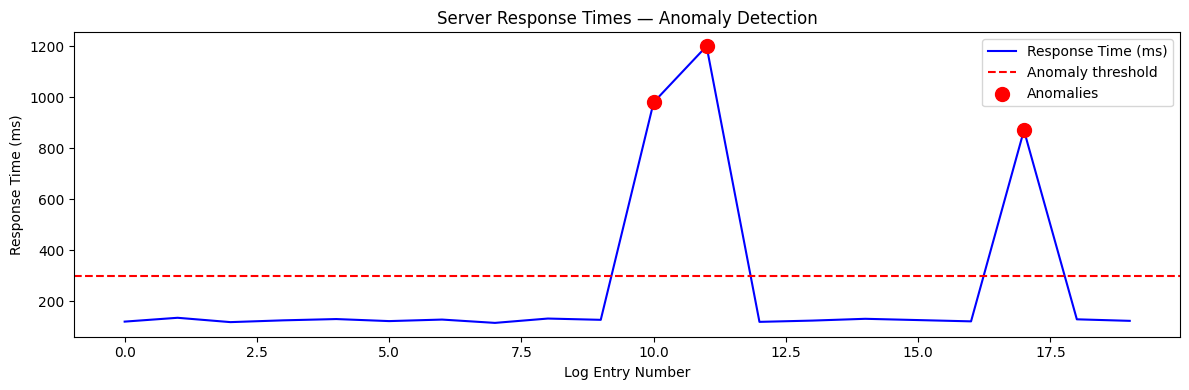

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(df['response_time_ms'], label='Response Time (ms)', color='blue')
plt.axhline(y=300, color='red', linestyle='--', label='Anomaly threshold')
plt.scatter(
    df[df['response_time_ms'] > 300].index,
    df[df['response_time_ms'] > 300]['response_time_ms'],
    color='red', zorder=5, s=100, label='Anomalies'
)
plt.title('Server Response Times — Anomaly Detection')
plt.xlabel('Log Entry Number')
plt.ylabel('Response Time (ms)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
anomalies = df[df['response_time_ms'] > 300]
print("Anomalous log entries:")
print(anomalies)
print(f"\nTotal anomalies: {len(anomalies)} out of {len(df)} entries")

Anomalous log entries:
              timestamp  response_time_ms  status_code  cpu_usage  \
10  2024-01-01 00:10:00               980          500         95   
11  2024-01-01 00:11:00              1200          500         98   
17  2024-01-01 00:17:00               870          503         91   

    memory_usage  error_count  
10            98           15  
11            99           22  
17            95           12  

Total anomalies: 3 out of 20 entries


In [18]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values per column:
timestamp           0
response_time_ms    0
status_code         0
cpu_usage           0
memory_usage        0
error_count         0
dtype: int64

Data types:
timestamp           object
response_time_ms     int64
status_code          int64
cpu_usage            int64
memory_usage         int64
error_count          int64
dtype: object
